# EPS 109 "Computer Simulations in Earth and Planetary Science"
### Instructor: Burkhard Militzer
### Combined lab and homework assignment on sound and audio files: Part 6


From bCourses, please download the file: "the_other_recording.wav" and apply the same steps as part 5: 

(1) Listen to the recording and write down what you hear:

I hear what sounds like water bieng poured into some sort of container. It sounds like water is being poured and I think I hear the sound of the water changing like it is being poured into something that is filling up

(2) Plot the sound amplitude as function of time:

Data rate [units of Hz = 1/seconds] =  44100
Array: data
shape: (529408,)
dtype: int16
min, max: -13945 12676



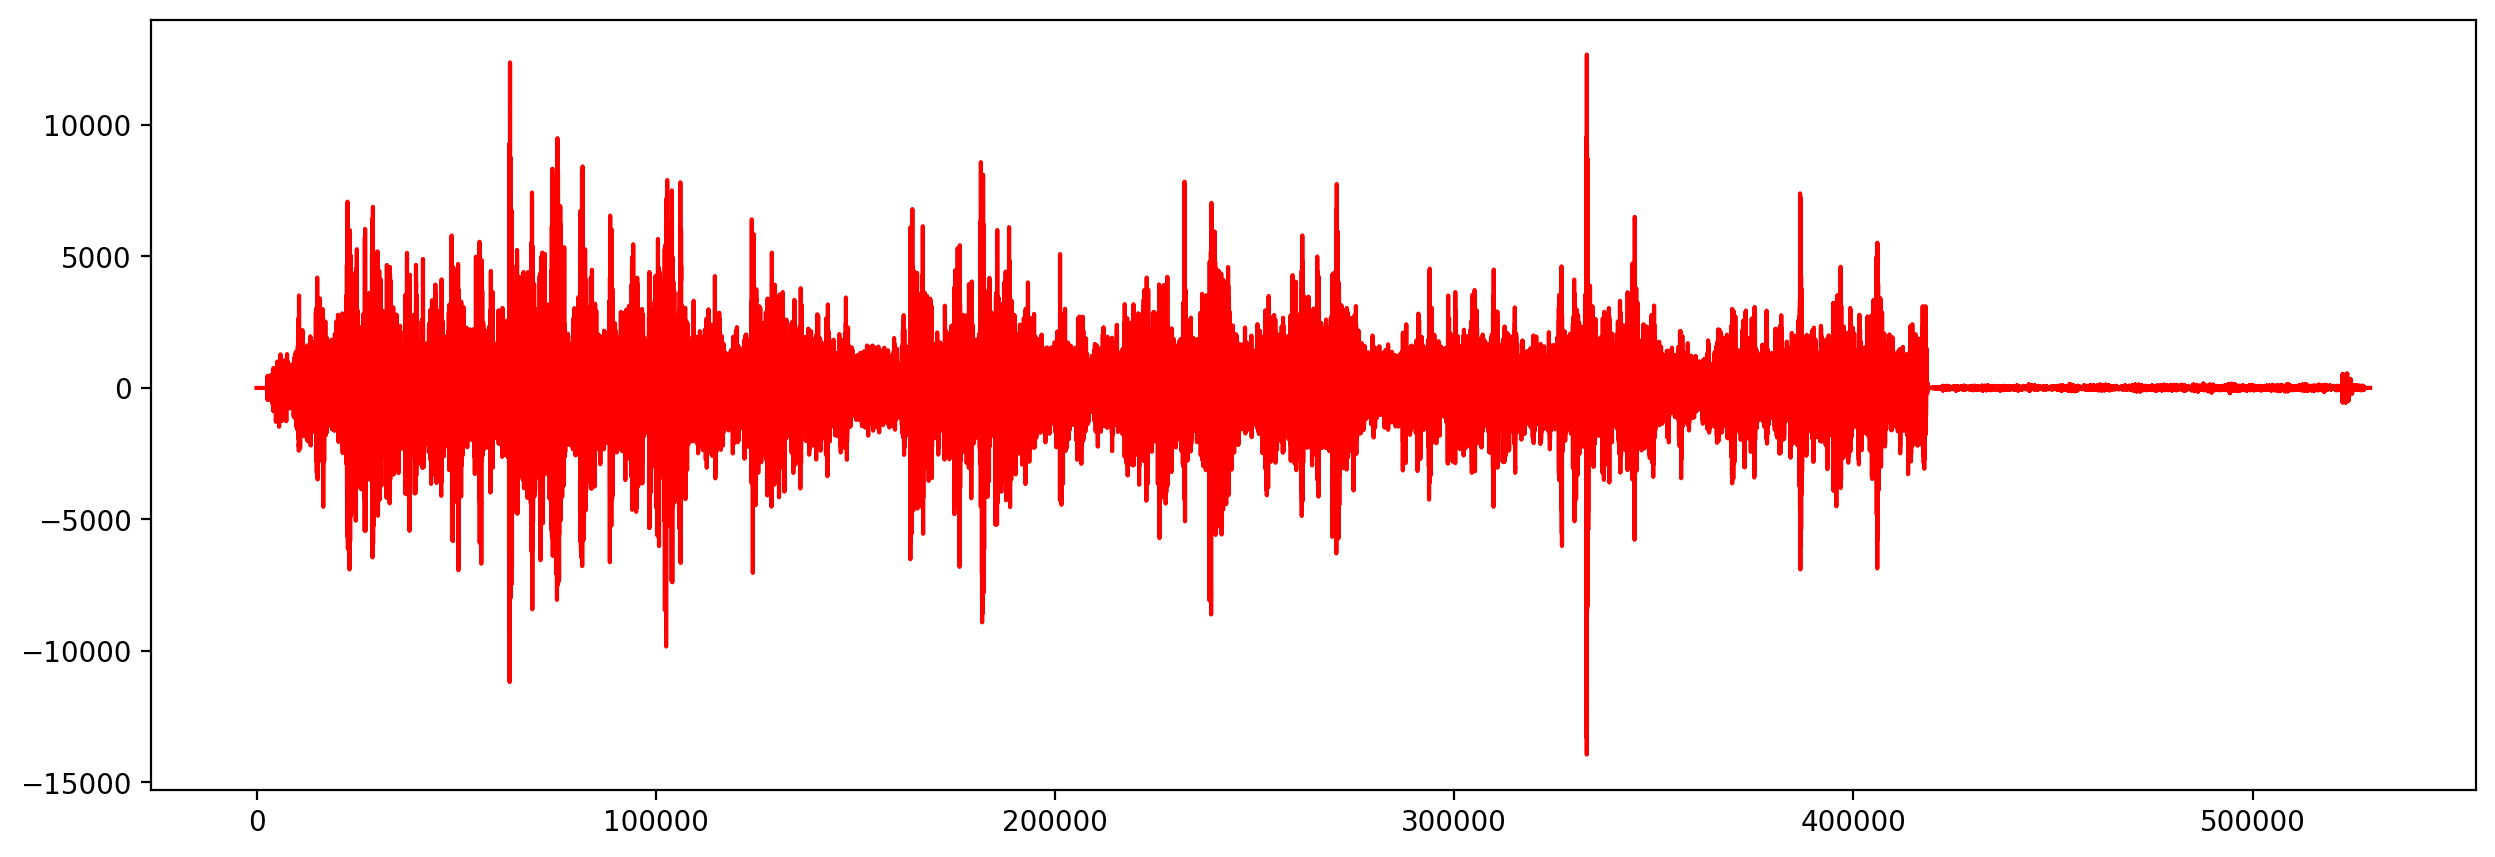

In [1]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
import numpy as np
import simpleaudio as sa
from scipy.io import wavfile

def PrintArrayInfo(a,name=''):
    if (len(name)==0):
        print("Array info:")
    else:
        print("Array:", name)
    print("shape:", a.shape)
    print("dtype:", a.dtype)
    print("min, max:", a.min(), a.max())
    print()

filename = 'the_other_recording.wav'
wave_obj = sa.WaveObject.from_wave_file(filename)
#play_obj = wave_obj.play()
#play_obj.wait_done()  # Wait until sound has finished playing

rate, data = wavfile.read(filename)
print("Data rate [units of Hz = 1/seconds] = ",rate)
PrintArrayInfo(data,"data")

plt.rcParams['figure.figsize'] = [15, 5]
plt.plot(data,'r-')
plt.show()

(3) Fourier transform the entire recording starting with a frequency in of 80 and ending with 5000. Then plot the Fourier transform as function of frequency index. You should see a wide range of frequencies. 

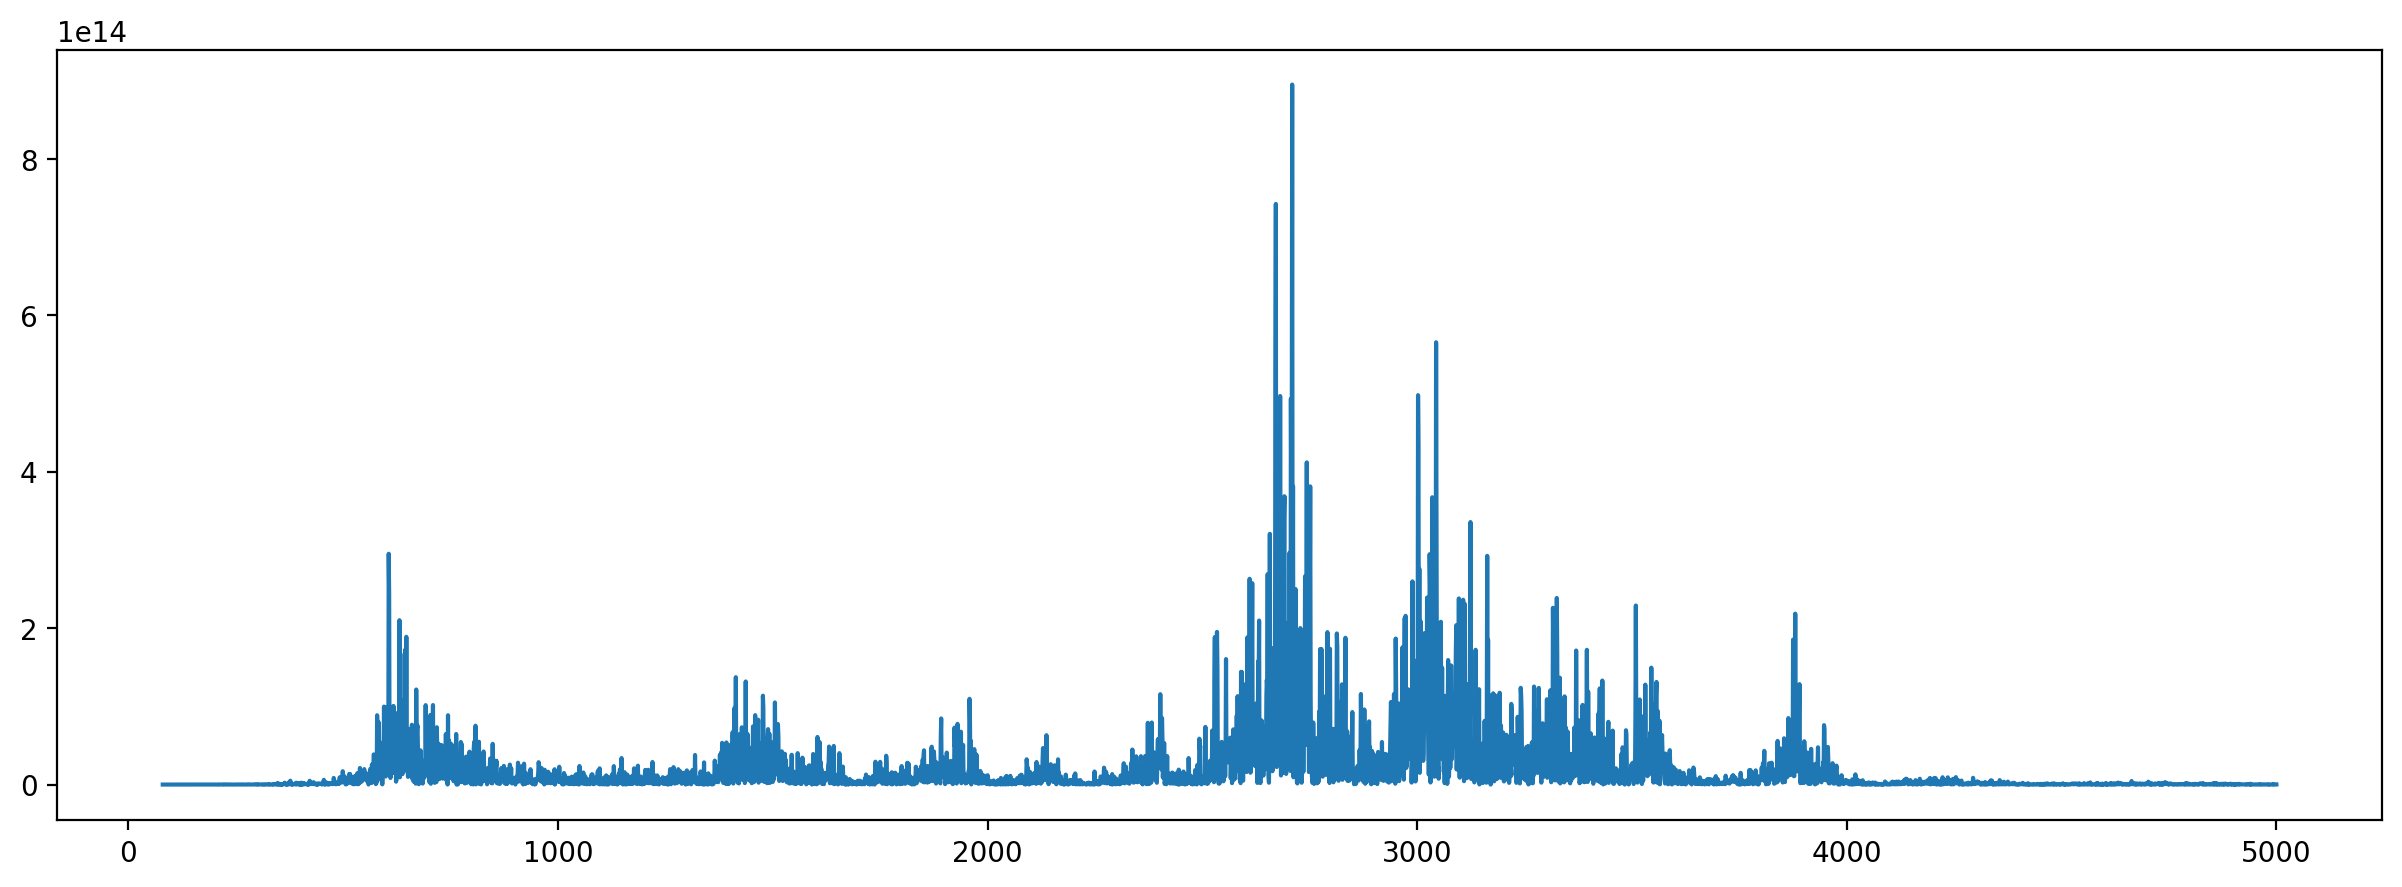

In [2]:
def fourier(x,k):
    n = len(x)
    j = np.arange(0,n)

    f_sin = np.sum(x * np.sin(2 * np.pi * j * k/n))
    f_cos = np.sum(x * np.cos(2 * np.pi * j * k/n))

    return f_sin**2 + f_cos**2

k1 = 80
k2 = 5000
frequency_indices = np.arange(80,5001)
frequency_indices_results = np.array([fourier(data,k) for k in frequency_indices])
plt.plot(frequency_indices,frequency_indices_results)

(4) Convert the frequencies indices 'k' for regular frequencies in units of Hertz (oscillations per second). Repeat the plot with frequency as X axis.

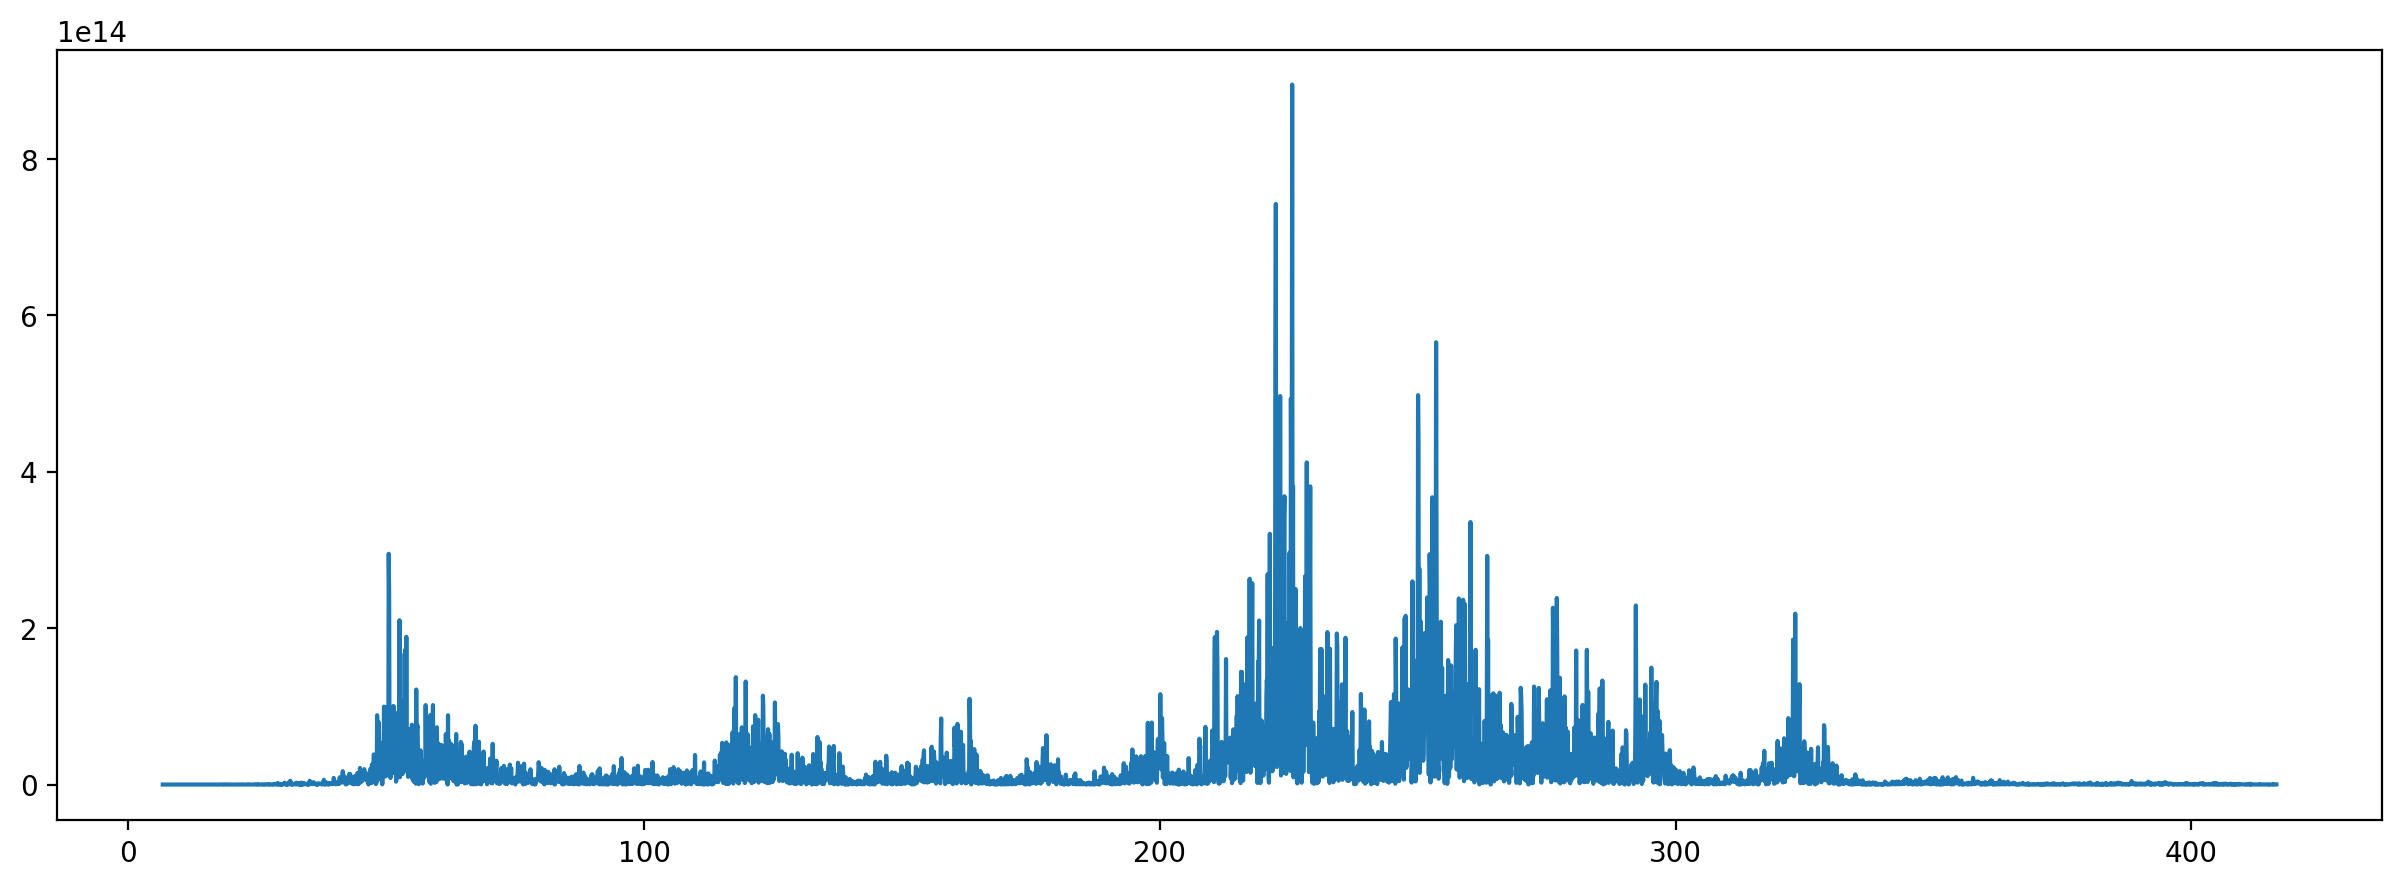

In [3]:
k1 = 80
k2 = 5000
frequency_indices = np.arange(80,5001)
frequency_hz = frequency_indices*(rate/len(data))
frequency_indices_results_hz = np.array([fourier(data,k) for k in frequency_indices])
plt.plot(frequency_hz,frequency_indices_results_hz)

(5) You should see a wide range of frequencies. Let's say the wave with the highest amplitude has a frequency f_max and an amplitude A_max. List the f_max in Hertz: 

In [8]:
peak_indices = np.argmax(frequency_indices_results_hz)
peak_frequency = frequency_hz[peak_indices]
print(peak_frequency)

225.6613047026112


In [9]:
# f_max = 225.66 Hertz

(6) You should see a wide range of frequencies. Let's say the wave with the highest amplitude has a frequency f_max and an amplitude A_max. Print f_max in Hertz:

In [10]:
# f_max = 225.66 Hertz
#I think this is a duplicate question

(7) To characterize the range of the present frequencies, print the lowest frequencies of all waves that have an amplidude of at least A_max/4.

In [18]:
threshold = np.max(frequency_indices_results_hz)/16
above_threshold_mask = frequency_indices_results_hz >= threshold
frequencies_above_threshold = frequency_hz[above_threshold_mask]
print(frequencies_above_threshold)

[ 48.23104298  48.39764416  48.56424535  49.56385245  49.73045364
  49.81375423  50.06365601  50.1469566   50.48015897  50.56345956
  50.97996252  51.2298643   51.39646549  51.47976608  51.56306667
  51.72966786  51.81296845  52.312772    52.39607259  52.47937319
  52.56267378  52.72927496  53.22907852  53.31237911  53.47898029
  53.56228089  53.72888207  53.89548326  54.31198622  54.39528681
  54.4785874   54.64518859  54.97839096  55.81139688  55.89469747
  55.97799807  56.06129866  57.64400991  58.56031643  58.8935188
  59.06011998  59.80982531  61.55913775  61.97564072  62.1422419
  63.55835197  67.30687863 117.12063286 117.20393345 117.53713582
 117.7870376  118.45344234 118.95324589 119.70295122 120.03615359
 121.11906129 121.53556425 122.03536781 122.1186684  123.03497492
 123.11827551 123.95128143 124.03458202 124.2844838  125.3673915
 125.95049565 126.03379624 133.61415015 157.52142015 157.60472074
 160.18703911 160.35364029 160.77014325 161.3532474  161.43654799
 163.10255984

In [19]:
bin_width = frequency_hz[0]-frequency_hz[1]
frequency_jumps = np.diff(frequencies_above_threshold)>(1.5*bin_width) #here I am finding where the waves are
start_indices = np.where(frequency_jumps)[0]+1
start_indices = np.insert(start_indices,0,0)

In [21]:
for i in range(len(start_indices)):
    if i == len(start_indices) - 1:
        group_frequencies = frequencies_above_threshold[start_indices[i]:]
    else:
        group_frequencies = frequencies_above_threshold[start_indices[i]:start_indices[i+1]]
    if len(group_frequencies) > 0:
        min_frequency = group_frequencies[0]
        print(f"wave {i+1}: {min_frequency:.3f} Hz")

wave 1: 48.231 Hz
wave 2: 48.398 Hz
wave 3: 48.564 Hz
wave 4: 49.564 Hz
wave 5: 49.730 Hz
wave 6: 49.814 Hz
wave 7: 50.064 Hz
wave 8: 50.147 Hz
wave 9: 50.480 Hz
wave 10: 50.563 Hz
wave 11: 50.980 Hz
wave 12: 51.230 Hz
wave 13: 51.396 Hz
wave 14: 51.480 Hz
wave 15: 51.563 Hz
wave 16: 51.730 Hz
wave 17: 51.813 Hz
wave 18: 52.313 Hz
wave 19: 52.396 Hz
wave 20: 52.479 Hz
wave 21: 52.563 Hz
wave 22: 52.729 Hz
wave 23: 53.229 Hz
wave 24: 53.312 Hz
wave 25: 53.479 Hz
wave 26: 53.562 Hz
wave 27: 53.729 Hz
wave 28: 53.895 Hz
wave 29: 54.312 Hz
wave 30: 54.395 Hz
wave 31: 54.479 Hz
wave 32: 54.645 Hz
wave 33: 54.978 Hz
wave 34: 55.811 Hz
wave 35: 55.895 Hz
wave 36: 55.978 Hz
wave 37: 56.061 Hz
wave 38: 57.644 Hz
wave 39: 58.560 Hz
wave 40: 58.894 Hz
wave 41: 59.060 Hz
wave 42: 59.810 Hz
wave 43: 61.559 Hz
wave 44: 61.976 Hz
wave 45: 62.142 Hz
wave 46: 63.558 Hz
wave 47: 67.307 Hz
wave 48: 117.121 Hz
wave 49: 117.204 Hz
wave 50: 117.537 Hz
wave 51: 117.787 Hz
wave 52: 118.453 Hz
wave 53: 118.953

(8) Now also print the highest frequencies of all waves that have an amplidude of at least A_max/4.

In [22]:
for i in range(len(start_indices)):
    if i == len(start_indices) - 1:
        group_frequencies = frequencies_above_threshold[start_indices[i]:]
    else:
        group_frequencies = frequencies_above_threshold[start_indices[i]:start_indices[i+1]]
    if len(group_frequencies) > 0:
        min_frequency = group_frequencies[-1]
        print(f"wave {i+1}: {min_frequency:.3f} Hz")

wave 1: 48.231 Hz
wave 2: 48.398 Hz
wave 3: 48.564 Hz
wave 4: 49.564 Hz
wave 5: 49.730 Hz
wave 6: 49.814 Hz
wave 7: 50.064 Hz
wave 8: 50.147 Hz
wave 9: 50.480 Hz
wave 10: 50.563 Hz
wave 11: 50.980 Hz
wave 12: 51.230 Hz
wave 13: 51.396 Hz
wave 14: 51.480 Hz
wave 15: 51.563 Hz
wave 16: 51.730 Hz
wave 17: 51.813 Hz
wave 18: 52.313 Hz
wave 19: 52.396 Hz
wave 20: 52.479 Hz
wave 21: 52.563 Hz
wave 22: 52.729 Hz
wave 23: 53.229 Hz
wave 24: 53.312 Hz
wave 25: 53.479 Hz
wave 26: 53.562 Hz
wave 27: 53.729 Hz
wave 28: 53.895 Hz
wave 29: 54.312 Hz
wave 30: 54.395 Hz
wave 31: 54.479 Hz
wave 32: 54.645 Hz
wave 33: 54.978 Hz
wave 34: 55.811 Hz
wave 35: 55.895 Hz
wave 36: 55.978 Hz
wave 37: 56.061 Hz
wave 38: 57.644 Hz
wave 39: 58.560 Hz
wave 40: 58.894 Hz
wave 41: 59.060 Hz
wave 42: 59.810 Hz
wave 43: 61.559 Hz
wave 44: 61.976 Hz
wave 45: 62.142 Hz
wave 46: 63.558 Hz
wave 47: 67.307 Hz
wave 48: 117.121 Hz
wave 49: 117.204 Hz
wave 50: 117.537 Hz
wave 51: 117.787 Hz
wave 52: 118.453 Hz
wave 53: 118.953